# Insurance Charges Prediction

## Names and student numbers:
- Emmanuel Fulfilled - X00227373
- Nathan Ford - X00229157
- Leo Ennis - X00226717
- Hady Yousef - X00219585

### Project Summary
This project predicts insurance charges using demographic and lifestyle features.  
The objective is supervised regression, predicting a continuous numeric target.



### Import Required Libraries

We import essential Python libraries for working with data, visualisation, and machine learning model development. This supports repeatability and establishes our technical environment for the project.

In [ ]:
import numpy as np
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



### Dataset Details
Source: Kaggle  Medical Insurance Costs Dataset (https://www.kaggle.com/datasets/saadaliyaseen/decoding-medical-costs-analyzing-insurance-data)

Rows: 1338  
Features: age, sex, bmi, children, smoker, region  
Target: charges

License: Public dataset 

In [ ]:
#Read in csv file as strings
filename = "insurance.csv"
data = pd.read_csv(filename)
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 1. Data cleaning and wrangling

Following best-practice guidelines, we check for:
- Missing values
- Duplicate records
- Incorrect or extreme values
- Data types


In [ ]:
# Missing values summary
data.isna().sum()


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

There's zero missing values in all columns

### Checked to see if there is any duplicate data

In [ ]:
#Detect any duplicate rows and drop them
duplicates = data.duplicated().sum()
print("Duplicate rows:", duplicates)

print("Data shape before dropping duplicates:", data.shape)


if duplicates > 0:
    data = data.drop_duplicates()

print(f"\nData shape after dropping duplicates:", data.shape)


Duplicate rows: 1
Data shape before dropping duplicates: (1338, 7)

Data shape after dropping duplicates: (1337, 7)


There was one duplicated row and it was dropped as seen in the printing of the data shape

In [ ]:
#Converted data values in sex and smoker columns to boolean
data['sex'] = data['sex'].map({'male': 1, 'female': 0})

data['smoker'] = data['smoker'].map({'yes': 1, 'no': 0})


Sex and Smoker Columns were converted to boolean for easier calculations and graphs

In [ ]:
data.describe()

,age,sex,bmi,children,smoker,charges
count,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,0.504862,30.663452,1.095737,0.204936,13279.121487
std,14.044333,0.500163,6.100468,1.205571,0.403806,12110.359656
min,18.000000,0.000000,15.960000,0.000000,0.000000,1121.873900
25%,27.000000,0.000000,26.290000,0.000000,0.000000,4746.344000
50%,39.000000,1.000000,30.400000,1.000000,0.000000,9386.161300
75%,51.000000,1.000000,34.700000,2.000000,0.000000,16657.717450
max,64.000000,1.000000,53.130000,5.000000,1.000000,63770.428010


## 2. Feature selection and pre processing

We separate data into training and testing subsets. This ensures that we can estimate generalisation performance on unseen data. The test set remains untouched until final evaluation in order to avoid data leakage.

We will also remove region as part of feature selection, we do not believe a region will effect peoples medical insurance as much as other factors such as smoking, bmi, sex, children and bmi.

In [ ]:
#Removing region as part of feature selection
print("Data shape before dropping any features:", data.shape)

data = data.drop('region', axis=1)

print("Data shape after dropping features:", data.shape)

X = data.drop('charges', axis=1)
y = data['charges'].astype(float)

feature_names = ["age", "sex", "bmi", "children", "smoker"]


print("Feature shape:", X.shape, "Target shape:", y.shape)

Data shape before dropping any features: (1337, 7)
Data shape after dropping features: (1337, 6)
Feature shape: (1337, 5) Target shape: (1337,)


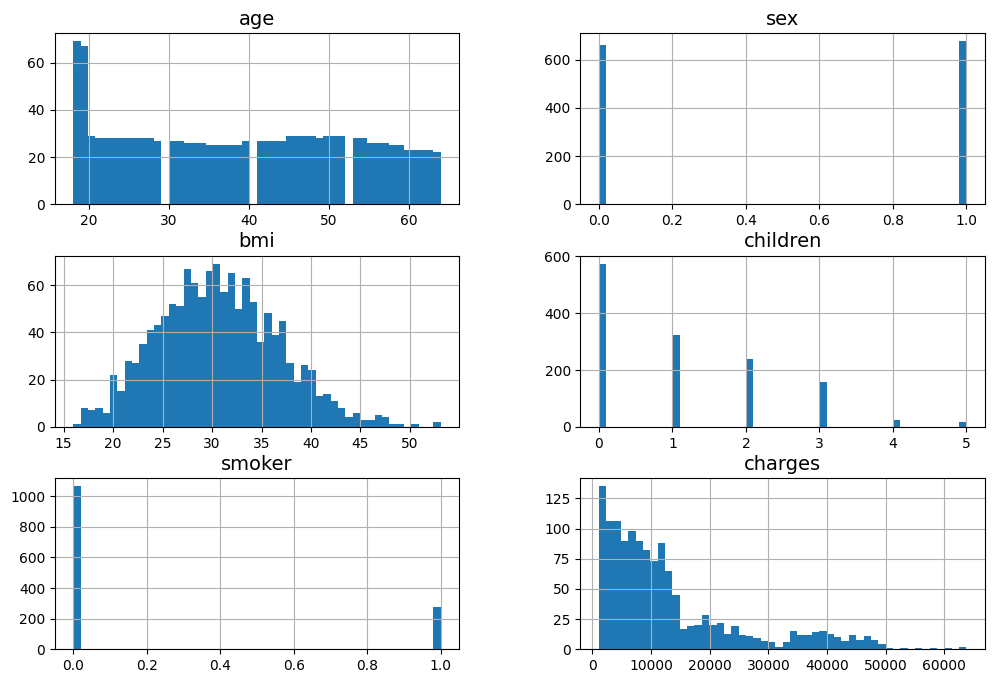

In [ ]:
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

data.hist(bins=50, figsize=(12, 8)) 

plt.show()

Some interesting things to note about the graphs above. 
* Age - There is a large amount of people in this data set around the age 20 and younger people tend not to have as much health problems so if most of the  people are young we can expect the charges to be on the low end.
* Children - Seems to be an even enough split on having kids and not having any,  
* BMI - Some BMIs are above 50 and below 15, this is expected due to the nature of different people having different body sizes. 
* Sex - 1 means male, 0 means female. We have an even spread.
* Smoker - 1 means yes, 0 means no. Since the majority do not smoke, we can expect lower charges.
* Charges - Majority of charges are on the low end below 10,000. There are some more expensive ones but this is expected due to some people being smokers, high bmi, different health conditions etc.

In [ ]:
plot_features = ["age", "bmi", "charges", "children"]

def find_outliers(arr, name):
    mean = arr.mean()
    std = arr.std()
    out_2std = arr[(arr > mean + 2*std) | (arr < mean - 2*std)]
    out_3std = arr[(arr > mean + 3*std) | (arr < mean - 3*std)]
    nan_count = np.isnan(arr).sum()
    print(f"\n{name}:")
    print(f" Mean={mean:.2f}, Std={std:.2f}")
    print(f"  Outliers >2σ: {len(out_2std)} values")
    print(f"  Outliers >3σ: {len(out_3std)} values")
    print(f"  Missing (NaN): {nan_count}")

for col in plot_features:
    find_outliers(data[col], col)


age:
 Mean=39.22, Std=14.04
  Outliers >2σ: 0 values
  Outliers >3σ: 0 values
  Missing (NaN): 0

bmi:
 Mean=30.66, Std=6.10
  Outliers >2σ: 57 values
  Outliers >3σ: 4 values
  Missing (NaN): 0

charges:
 Mean=13279.12, Std=12110.36
  Outliers >2σ: 107 values
  Outliers >3σ: 7 values
  Missing (NaN): 0

children:
 Mean=1.10, Std=1.21
  Outliers >2σ: 43 values
  Outliers >3σ: 18 values
  Missing (NaN): 0


* Age - well documented and doesnt contain any outliers. 
* BMI - shows several outliers however this is expected due to individuals having a wide range of shapes and sizes. 
* Charges - have the widest range of outliers which reflects the cost associated with factors such as bmi, if they are a smoker etc. 
* Children - has  outliers due to different family situations.

Based off the nature of the insurance dataset both charges and bmi were expected to have outliers. Children was also expected to have outliers due to varying family sizes. 

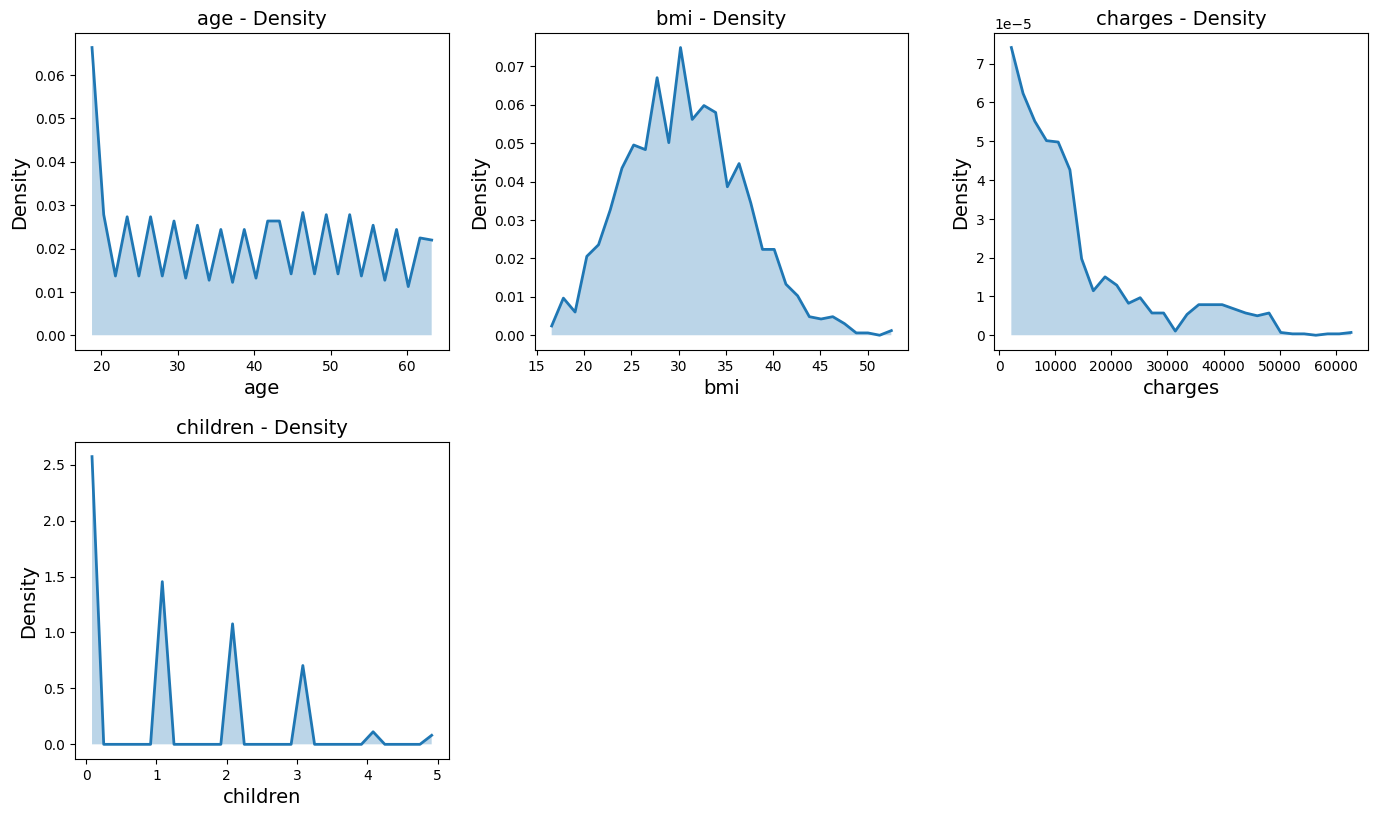

In [ ]:
plt.figure(figsize=(14, 12))

for i, fname in enumerate(plot_features):
    values = data[fname].values  # <-- change here
    
    counts, bins = np.histogram(values, bins=30, density=True)
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    
    plt.subplot(3, 3, i+1)
    plt.plot(bin_centers, counts, linewidth=2)
    plt.fill_between(bin_centers, counts, alpha=0.3)
    plt.title(f"{fname} - Density")
    plt.xlabel(fname)
    plt.ylabel("Density")

plt.tight_layout()
plt.show()

These density graphs are similar to the count graphs displayed but highlight our main plot features. 
* Age - has a higher concentration of younger adults 18-30.
* BMI - highest concentration around 25-35
* Charges - Most charges are on the lower end with a few rare cases on the higher end.
* Children - A high concentration of people have no kids. Having more kids is uncommon with very few having more than 3.

This is splitting the data into training and testing sets.

In [ ]:
#splits the data into different sets the test size means that that percentage will be set aside for test data while the random state keeps the model replicable
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (935, 5)
Validation: (201, 5)
Test: (201, 5)


## 3. Model and Model comparison

This is the linear regression model

For the four models used. We used 3 evaluation metric: 
1. R²(Coefficient of Determination): Shows how well the model explainsthe variations in the data
2. MAE(Mean Absolute Error): Measures the average size of the errors.
3. RMSE(Root Mean Squared Error): Measures how far predictions are from the true values on average, with larger mistakes punished more heavily because the errors are squared before averaging.

I used geeksforgeeks (https://www.geeksforgeeks.org/machine-learning/python-linear-regression-using-sklearn/) to better understand all the models i chose.

In [ ]:
linReg = linear_model.LinearRegression()
linReg.fit(X_train, y_train)

y_test_lin = linReg.predict(X_test)
y_val_lin = linReg.predict(X_val)


val_r2_lin = r2_score(y_val, y_val_lin)
test_r2_lin = r2_score(y_test, y_test_lin)

val_rmse_lin = np.sqrt(mean_squared_error(y_val, y_val_lin))
test_rmse_lin = np.sqrt(mean_squared_error(y_test, y_test_lin))


val_mae_lin = mean_absolute_error(y_val, y_val_lin)
test_mae_lin = mean_absolute_error(y_test, y_test_lin)

print("Linear Regression")
print("Validation: R² =", val_r2_lin, "RMSE =", val_rmse_lin, "MAE =", val_mae_lin)
print("Test:       R² =", test_r2_lin, "RMSE =", test_rmse_lin, "MAE =", test_mae_lin)



Linear Regression
Validation: R² = 0.7641609460992383 RMSE = 6352.04551855208 MAE = 4349.01835593007
Test:       R² = 0.7769325172654449 RMSE = 6169.934314604173 MAE = 4034.7920794241927


This is the plotted result of the Linear Regression model

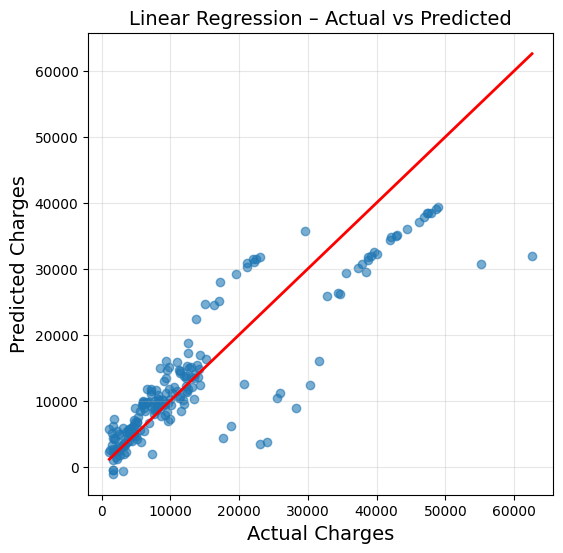

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_lin, alpha=0.6)
perfect_line = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(perfect_line, perfect_line, color="red", linewidth=2)
plt.title("Linear Regression – Actual vs Predicted")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.grid(alpha=0.3)
plt.show()


This graph suggests that Linear Regression captures the basic pattern well but it struggles on complex or extreme cases where medical charges rise sharply

This is the KNN (K-Nearest Neighbours) Regression model

In [ ]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

y_val_knn = knn.predict(X_val)
y_test_knn = knn.predict(X_test)


val_r2_knn = r2_score(y_val, y_val_knn)
test_r2_knn = r2_score(y_test, y_test_knn)

val_rmse_knn = np.sqrt(mean_squared_error(y_val, y_val_knn))
test_rmse_knn = np.sqrt(mean_squared_error(y_test, y_test_knn))

val_mae_knn = mean_absolute_error(y_val, y_val_knn)
test_mae_knn = mean_absolute_error(y_test, y_test_knn)


print("KNN Regressor")
print("Validation: R² =", val_r2_knn, "RMSE =", val_rmse_knn, "MAE =", val_mae_knn)
print("Test:       R² =", test_r2_knn, "RMSE =", test_rmse_knn, "MAE =", test_mae_knn)




KNN Regressor
Validation: R² = 0.19965261033710135 RMSE = 11701.593469394147 MAE = 7614.317502676616
Test:       R² = 0.14315701235599299 RMSE = 12092.41465012137 MAE = 7957.653663646765


This is the plotted result of KNN Regression model

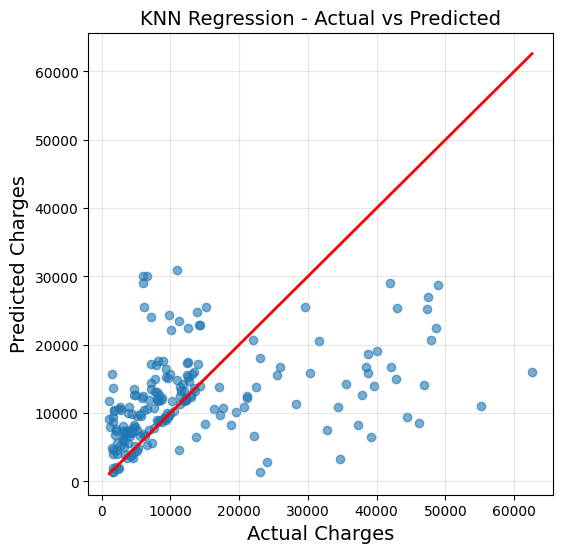

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_knn, alpha=0.6)
perfect_line = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(perfect_line, perfect_line, color="red", linewidth=2)
plt.title("KNN Regression - Actual vs Predicted")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.grid(alpha=0.3)
plt.show()


This graph shows that the KNN Regressor struggles to generalise the data pattern well. Many predictions are far from the diagonal line, especially for medium and high insurance charges. KNN tends to predict closer to the average values, causing large errors when real charges are high.
This suggests KNN is not suitable for modeling the complex relationships in this dataset.

## This is Decision Tree Regression

In [ ]:
decReg = DecisionTreeRegressor(max_depth=2, random_state=42)
decReg.fit(X_train, y_train)

y_val_decReg = decReg.predict(X_val)
y_test_decReg = decReg.predict(X_test)

val_r2_decReg = r2_score(y_val, y_val_decReg)
test_r2_decReg = r2_score(y_test, y_test_decReg)

val_rmse_decReg = np.sqrt(mean_squared_error(y_val, y_val_decReg))
test_rmse_decReg = np.sqrt(mean_squared_error(y_test, y_test_decReg))

val_mae_decReg = mean_absolute_error(y_val, y_val_decReg)
test_mae_decReg = mean_absolute_error(y_test, y_test_decReg)


print("Decision Tree Regressor")
print("Validation: R² =", val_r2_decReg, "RMSE =", val_rmse_decReg, "MAE =", val_mae_decReg)
print("Test:       R² =", test_r2_decReg, "RMSE =", test_rmse_decReg, "MAE =", test_mae_decReg)


Decision Tree Regressor
Validation: R² = 0.8329522846853393 RMSE = 5345.963751885502 MAE = 3458.1108149051024
Test:       R² = 0.8403422411028445 RMSE = 5219.842772383215 MAE = 3388.174029039086


This is the plot for Decision tree Regression

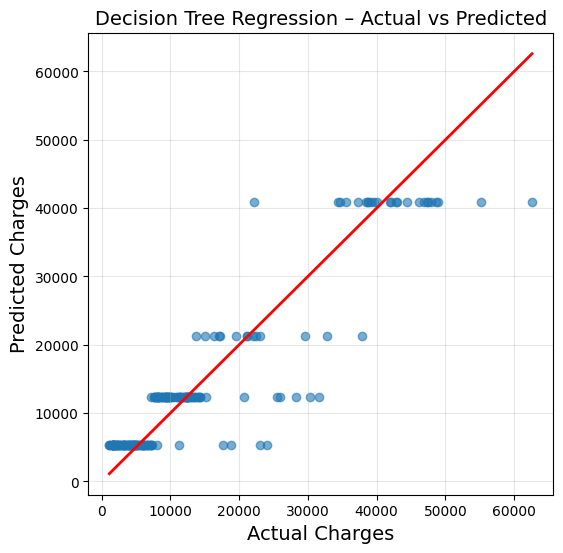

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_decReg, alpha=0.6)
perfect_line = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(perfect_line, perfect_line, color="red", linewidth=2)
plt.title("Decision Tree Regression – Actual vs Predicted")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.grid(alpha=0.3)
plt.show()

This graph shows strong underfitting, predictions cluster into a few flat horizontal bands because the tree is shallow, it makes only a limited number of output values. Points are mostly far from the diagonal, especially for extreme cases. This suggests the model is too simple to capture the variability in insurance costs.


This is Random Forest Regression

In [ ]:
RandForReg = RandomForestRegressor(n_estimators=100, random_state=42, oob_score=True)
RandForReg.fit(X_train, y_train)

y_val_rf = RandForReg.predict(X_val)
y_test_rf = RandForReg.predict(X_test)


val_r2_rf = r2_score(y_val, y_val_rf)
test_r2_rf = r2_score(y_test, y_test_rf)

val_rmse_rf = np.sqrt(mean_squared_error(y_val, y_val_rf))
test_rmse_rf = np.sqrt(mean_squared_error(y_test, y_test_rf))

val_mae_rf = mean_absolute_error(y_val, y_val_rf)
test_mae_rf = mean_absolute_error(y_test, y_test_rf)


oob_score_RandForReg = RandForReg.oob_score_

print("\nRandom Forest Regressor")
print("Validation: R² =", val_r2_rf, "RMSE =", val_rmse_rf, "MAE =", val_mae_rf)
print("Test:       R² =", test_r2_rf, "RMSE =", test_rmse_rf, "MAE =", test_mae_rf)
print("Out-of-Bag Score (Training Reference):", oob_score_RandForReg)



Random Forest Regressor
Validation: R² = 0.8609005068185427 RMSE = 4878.300099590922 MAE = 2600.3883353079614
Test:       R² = 0.8500733275850226 RMSE = 5058.268264529074 MAE = 2746.2159119810935
Out-of-Bag Score (Training Reference): 0.8125776199259913


This is the plot for Random Forest Regression

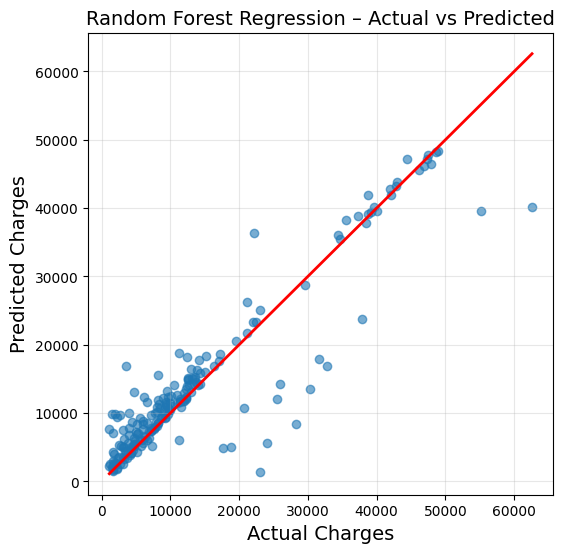

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_rf, alpha=0.6)
perfect_line = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(perfect_line, perfect_line, color="red", linewidth=2)
plt.title("Random Forest Regression – Actual vs Predicted")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.grid(alpha=0.3)
plt.show()


This graph demonstrates the best model performance. Most points are close to the diagonal, meaning predictions closely match actual values. The model handles both lower and higher charges more accurately than the others.
It captures the non-linear patterns in the data and reduces the errors seen in simpler models.


## 4. Evaluation

### Why these Models?

#### Linear Regression
- Linear Regression is like fitting a straight line through the data points.
- It is our first guess / baseline model to work with.
- We use this first because its simple and if it cant beat a simple straight line then maybe we don't need to use complex / fancy algorithms.

#### KNN Regressor
- By looking at the k most similar examples in the training data KNN predicts the outcomes.
- When similar things behave in a similar way thats when KNN works the best.
- To ensure fair metrics normalization is generally required.

#### Decision Tree Regressor
- It can overfit by memorizing training data.
- Both numeric and categorical features are handled well.
- Feature scaling is not necessary because it learns non-linear rules.
#### Random Forest Regressor
- Better generalisation and reduced variance compared to a single decision tree.
- Performance is strong on complex datasets.
- Outliers are handled effictively by reducing the negative impact.

### Model Performance Comparison

We compile the cross validation results into a comparison table in order to identify the strongest model. Models with higher R² and lower MAE and RMSE are preferred. This supports a justified and traceable decision on the final chosen model.

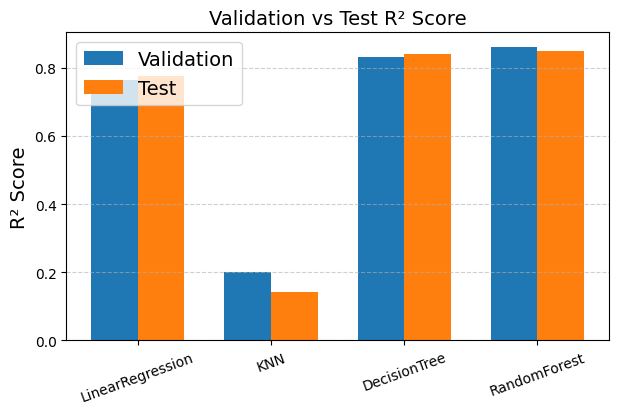

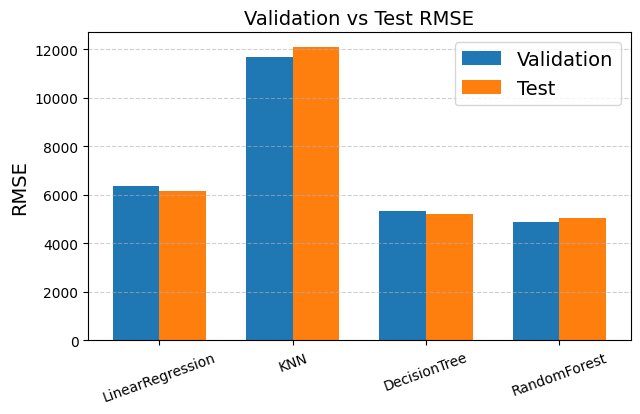

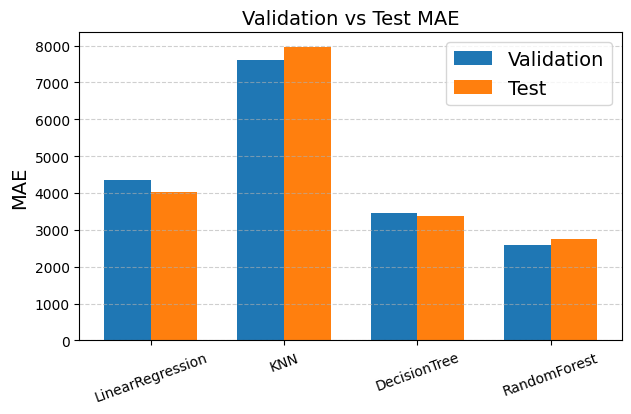

In [ ]:
# List of name of models 
models = ["LinearRegression", "KNN", "DecisionTree", "RandomForest"]

# Validation metrics for each model.
val_r2 = [val_r2_lin, val_r2_knn, val_r2_decReg, val_r2_rf]
val_rmse = [val_rmse_lin, val_rmse_knn, val_rmse_decReg, val_rmse_rf]
val_mae = [val_mae_lin, val_mae_knn, val_mae_decReg, val_mae_rf]

# Test metrics for each model.
test_r2 = [test_r2_lin, test_r2_knn, test_r2_decReg, test_r2_rf]
test_rmse = [test_rmse_lin, test_rmse_knn, test_rmse_decReg, test_rmse_rf]
test_mae = [test_mae_lin, test_mae_knn, test_mae_decReg, test_mae_rf]
# list of metrics for both validation and test models.
metrics = [
    ("R² Score", val_r2, test_r2),
    ("RMSE", val_rmse, test_rmse),
    ("MAE", val_mae, test_mae)
]

for metric_name, val_scores, test_scores in metrics:    # Generates bar charts by looping each metric.
    x = np.arange(len(models))
    width = 0.35

    plt.figure(figsize=(7, 4))  # figure size.
    plt.bar(x - width/2, val_scores, width, label="Validation")
    plt.bar(x + width/2, test_scores, width, label="Test")
    plt.xticks(x, models, rotation=20)
    plt.ylabel(metric_name)
    plt.title(f"Validation vs Test {metric_name}")  # Title of chart.
    plt.legend()    # To differentiate bars.
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()  # Outputs the charts.


The bar charts above show us the difference in performance across all four models. We can highlight that the Random Forest Regressor model achieves the highest R² (R-squared) and the lowest RMSE (Root Mean Squared Error) and MAE (Mean Absolute Error) which generally indicates that it is the best model on both validation data and test data.

### Best Model

In [ ]:
# R² scores validation for each model
val_scores = {
    "Linear Regression": val_r2_lin,  
    "KNN Regressor": val_r2_knn,     
    "Decision Tree Regressor": val_r2_decReg,
    "Random Forest Regressor": val_r2_rf
}


best_model_name = max(val_scores, key=val_scores.get)   # Model name using the higest R²
print("Best model: ", best_model_name)

# This code is for showing the model object to select the modl name. 
best_model = {
    "Linear Regression": linReg,
    "KNN Regressor": knn,
    "Decision Tree Regressor": decReg,
    "Random Forest Regressor": RandForReg
}[best_model_name]

Best model:  Random Forest Regressor


### Feature Importance

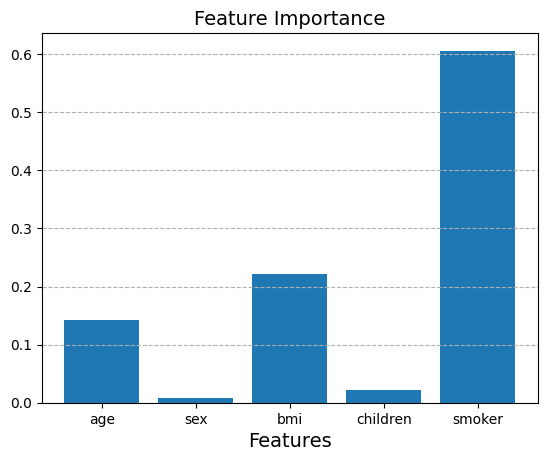

In [ ]:
feat_imp=best_model.feature_importances_    # Best model is extracted by feature importance.
# X.columns shows each feature name and generates the bar chart.
# feat_imp just displays the height of the bar chart by their importance.
plt.bar(X.columns,feat_imp)
plt.title("Feature Importance") # y-axis is changed to the term "Feature Importance".
plt.xlabel("Features")  # x-axis is changed to the term "Features".
plt.grid(axis="y", linestyle="--")  # This just makes it better to read the bar plot.
plt.show()  # Outputs bar plot.

The bar plot above shows that smoker is the most important feature, while bmi and age also contribute meaningfully, sex and children have minimal importance.
Meaning little to no gender bias in the predictions

### Overfitting And Underfitting

#### Linear Regression
- There was no overfitting issues with this model, but there some slight underfitting issues.

#### KNN Regressor
- Underfitting due to poor performance on validation and testing.

#### Decision Tree Regressor
- Some variation in generalisation, due to the difference between (validation) R² = 0.795 AND (test) R² = 0.867
#### Random Forest Regressor
- Little overfitting - very similar validation and test performances.



Linear Regression suffered from underfitting more than overfitting aswell as KNN this is due to the fact that both models is limited to complex patterns. Overfitting was detected in the Decision Tree model due to the high complexity of the model. Generalisation was perfect for Random Forest and its deployment is more reliable.

## 5.Ethical considerations

Insurance pricing can amplify unfair discrimination if the model learns that some groups such as smokers or certain genders should always pay more.
The dataset may reflect past societal bias rather than genuine cost differences.
We mitigate this by scaling only numerical fields and using one hot encoding to avoid ordering in categorical data.

## 6. Best Model Saved

In [ ]:
joblib.dump(best_model, "best_regression_model.joblib") # Using joblib to save the best model selected.
print("Saved best model to best_regression_model.joblib")

Saved best model to best_regression_model.joblib


Saved the best model so it's accessible for use with the demo